## 01 작업 내용
1. CS2_35 Excel 읽기
2. 시트명 확인
3. 컬럼명 확인
4. 데이터 값 확인
5. Cycle_Index, Current(A), Voltage(V), Discharge_Capacity(Ah) 분포 확인

## 01 체크사항
1. Excel 파일 25개가 모두 잡히는가?
2. 모든 파일에 Channel_1-008 시트가 있는가?
3. 필수 컬럼이 모두 있는가?
4. Discharge_Capacity(Ah)를 cycle별 capacity로 써도 되는가?

In [1]:
# 엑셀 파일 읽기
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "calce" / "CS2" / "CS2_35"

# 문자열 정렬
files = sorted(RAW_DIR.glob("*.xlsx"))

print("raw dir:", RAW_DIR)
print("file count:", len(files))
files[:5]


raw dir: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35
file count: 25


[PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_10_15_10.xlsx'),
 PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_10_22_10.xlsx'),
 PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_10_29_10.xlsx'),
 PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_11_01_10.xlsx'),
 PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_11_08_10.xlsx')]

In [4]:
# 샘플 엑셀 파일 지정
sample_path = files[0]

xls = pd.ExcelFile(sample_path)
xls.sheet_names

['Info', 'Channel_1-008']

In [5]:
# 샘플 엑셀 파일 "Channel_1-008" 시트의 데이터 읽기
df = pd.read_excel(sample_path, sheet_name="Channel_1-008")
print(df.shape)
df.head()

(17139, 17)


,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,30.000525,2010-10-08 14:29:45,30.000525,1,1,0.000000,3.424221,0.000000,0.0,0.000000,0.0,0.000032,0.0,0,0,0
1,2,60.015702,2010-10-08 14:30:15,60.015703,1,1,0.000000,3.424382,0.000000,0.0,0.000000,0.0,0.000032,0.0,0,0,0
2,3,90.030813,2010-10-08 14:30:45,90.030813,1,1,0.000000,3.424382,0.000000,0.0,0.000000,0.0,0.000032,0.0,0,0,0
3,4,120.014345,2010-10-08 14:31:15,120.014346,1,1,0.000000,3.424382,0.000000,0.0,0.000000,0.0,0.000000,0.0,0,0,0
4,5,150.030510,2010-10-08 14:31:46,30.015733,2,1,0.550117,3.567489,0.004587,0.0,0.016232,0.0,0.001392,0.0,0,0,0


In [6]:
# 엑셀파일 컬럼명 확인
df.columns.tolist()

['Data_Point',
 'Test_Time(s)',
 'Date_Time',
 'Step_Time(s)',
 'Step_Index',
 'Cycle_Index',
 'Current(A)',
 'Voltage(V)',
 'Charge_Capacity(Ah)',
 'Discharge_Capacity(Ah)',
 'Charge_Energy(Wh)',
 'Discharge_Energy(Wh)',
 'dV/dt(V/s)',
 'Internal_Resistance(Ohm)',
 'Is_FC_Data',
 'AC_Impedance(Ohm)',
 'ACI_Phase_Angle(Deg)']

In [7]:
# 엑셀파일 컬럼들 중 중요 컬럼 확인
required_cols = [
    "Cycle_Index",
    "Test_Time(s)",
    "Step_Time(s)",
    "Current(A)",
    "Voltage(V)",
    "Charge_Capacity(Ah)",
    "Discharge_Capacity(Ah)",
]

missing_cols = [col for col in required_cols if col not in df.columns]
missing_cols

[]

In [16]:
df[required_cols].describe()

,Cycle_Index,Test_Time(s),Step_Time(s),Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah)
count,17139.000000,17139.000000,17139.000000,17139.000000,17139.000000,17139.000000,17139.000000
mean,25.223234,292648.678070,2278.564214,-0.015668,3.860026,25.639330,25.099522
std,14.445123,169384.920501,1668.756204,0.767062,0.241481,14.701833,14.701259
min,1.000000,30.000525,0.000002,-1.100291,2.699458,0.000000,0.000000
25%,13.000000,146539.489321,840.425122,-1.099568,3.714724,12.823441,12.556234
50%,25.000000,291252.721956,2101.044447,0.549936,3.900488,25.747109,24.854453
75%,38.000000,438771.485905,3361.699856,0.550117,4.026921,38.309035,37.917181
max,50.000000,588816.782714,6164.946798,1.014463,4.200139,50.996669,50.935903


In [10]:
# 엑셀파일 중요 컬럼들 요약
df[required_cols].info()
df[required_cols].isnull().sum()
df[required_cols].dtypes

<class 'pandas.DataFrame'>
RangeIndex: 17139 entries, 0 to 17138
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cycle_Index             17139 non-null  int64  
 1   Test_Time(s)            17139 non-null  float64
 2   Step_Time(s)            17139 non-null  float64
 3   Current(A)              17139 non-null  float64
 4   Voltage(V)              17139 non-null  float64
 5   Charge_Capacity(Ah)     17139 non-null  float64
 6   Discharge_Capacity(Ah)  17139 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 937.4 KB


Cycle_Index                 int64
Test_Time(s)              float64
Step_Time(s)              float64
Current(A)                float64
Voltage(V)                float64
Charge_Capacity(Ah)       float64
Discharge_Capacity(Ah)    float64
dtype: object

In [11]:
# Cycle_Index별로 데이터 요약
cycle_summary = (
    df.groupby("Cycle_Index")
    .agg(
        row_count=("Data_Point", "count"),
        test_time_min=("Test_Time(s)", "min"),
        test_time_max=("Test_Time(s)", "max"),
        voltage_mean=("Voltage(V)", "mean"),
        voltage_min=("Voltage(V)", "min"),
        voltage_max=("Voltage(V)", "max"),
        current_mean=("Current(A)", "mean"),
        charge_capacity_max=("Charge_Capacity(Ah)", "max"),
        discharge_capacity_max=("Discharge_Capacity(Ah)", "max"),
    )
    .reset_index()
)

cycle_summary.head()

,Cycle_Index,row_count,test_time_min,test_time_max,voltage_mean,voltage_min,voltage_max,current_mean,charge_capacity_max,discharge_capacity_max
0,1,355,30.000525,12388.083434,3.865775,2.699782,4.200139,-0.005022,1.075997,1.041556
1,2,349,12418.114690,24549.184493,3.863152,2.699944,4.200139,-0.019196,2.118313,2.085898
2,3,352,24579.217156,36620.009252,3.863101,2.699620,4.200139,-0.014313,3.164123,3.133029
3,4,352,36650.041830,48685.029251,3.862044,2.699782,4.200139,-0.014620,4.211374,4.180907
4,5,352,48715.062209,60746.188566,3.861415,2.699458,4.200139,-0.014239,5.259143,5.228866


In [17]:
# capacity 누적 여부 확인
capacity_check = cycle_summary[
    [
        "Cycle_Index",
        "charge_capacity_max",
        "discharge_capacity_max",
    ]
].copy()

capacity_check["discharge_capacity_diff"] = (
    capacity_check["discharge_capacity_max"]
    .diff()
    .fillna(capacity_check["discharge_capacity_max"])
)

capacity_check.head(10)

,Cycle_Index,charge_capacity_max,discharge_capacity_max,discharge_capacity_diff
0,1,1.075997,1.041556,1.041556
1,2,2.118313,2.085898,1.044342
2,3,3.164123,3.133029,1.047132
3,4,4.211374,4.180907,1.047877
4,5,5.259143,5.228866,1.047960
5,6,6.306738,6.276477,1.047611
6,7,7.354115,7.324014,1.047537
7,8,8.401460,8.371716,1.047702
8,9,9.448770,9.419002,1.047286
9,10,10.495639,10.465630,1.046629


In [13]:
cycle_summary.shape

(50, 10)

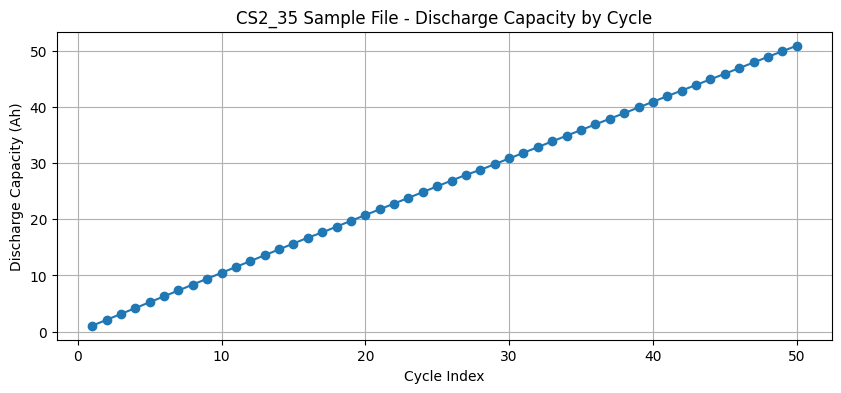

In [14]:
# Cycle_Index별 데이터 시각화
import matplotlib.pyplot as plt
cycle_summary[
    [
        "Cycle_Index",
        "row_count",
        "charge_capacity_max",
        "discharge_capacity_max",
        "voltage_mean",
        "current_mean",
    ]
]
plt.figure(figsize=(10, 4))
plt.plot(
    cycle_summary["Cycle_Index"],
    cycle_summary["discharge_capacity_max"],
    marker="o",
)
plt.title("CS2_35 Sample File - Discharge Capacity by Cycle")
plt.xlabel("Cycle Index")
plt.ylabel("Discharge Capacity (Ah)")
plt.grid(True)
plt.show()

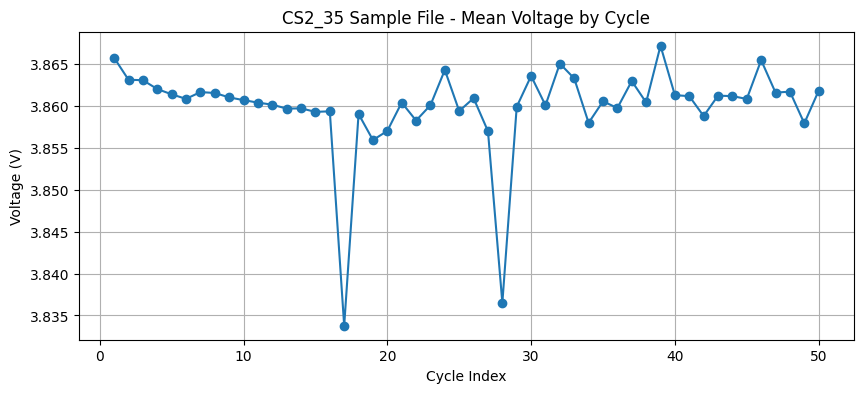

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(
    cycle_summary["Cycle_Index"],
    cycle_summary["voltage_mean"],
    marker="o",
)
plt.title("CS2_35 Sample File - Mean Voltage by Cycle")
plt.xlabel("Cycle Index")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

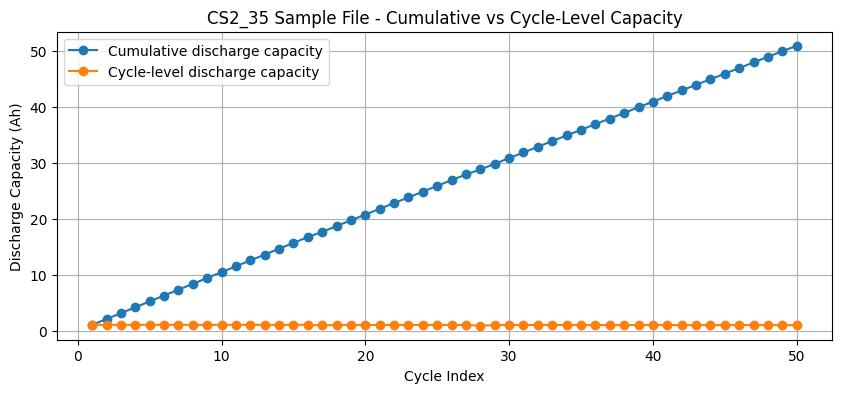

In [18]:
# capacity 누적 여부 시각화
plt.figure(figsize=(10, 4))
plt.plot(
    capacity_check["Cycle_Index"],
    capacity_check["discharge_capacity_max"],
    marker="o",
    label="Cumulative discharge capacity",
)
plt.plot(
    capacity_check["Cycle_Index"],
    capacity_check["discharge_capacity_diff"],
    marker="o",
    label="Cycle-level discharge capacity",
)
plt.title("CS2_35 Sample File - Cumulative vs Cycle-Level Capacity")
plt.xlabel("Cycle Index")
plt.ylabel("Discharge Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()